# Correction of the binning estimate bias

Reference: ["Analytical estimates of limited sampling biases in different information measures",
S. Panzeri, A. Treves, Network: Computation in Neural Systems, 1996](https://doi.org/10.1080/0954898X.1996.11978656).


In [1]:
%load_ext autoreload
%autoreload 2 

from numba import njit

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

import neuro_lib as nlib
from neuro_lib.core import mi_binning_2d_numba

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

Finite-sample bias:

$$\mathbb{E}[\hat{I_N(R)}] - I(R) = \frac{1}{2N \ln 2} \left( K_{XY} - K_X - K_Y + 1 \right) + O\left(\frac{1}{N^2}\right)$$

1. $I(R) \rightarrow I$ for $R\rightarrow +\infty$ and $I(R) < I$ (downward bias)
2. $I_N(R) \rightarrow I(R)$ for $N\rightarrow +\infty$ from above (upward bias) with a systematic error that scales with $R/N$ 


As a result of 1. and 2. combined, to estimate accurately the differential mi, I, you need a large number of bins R, but at the same time, given you have limited samples N, you cannot take R too large. You must do a compromise between the two sources of error.

The fact that one bias is downwards and the other is upwards is good because you can hope to find a sweet spot where the two compensate.

### Compute (approximately) I(R) at varying R, check that it tends to I asymptotically, from below.

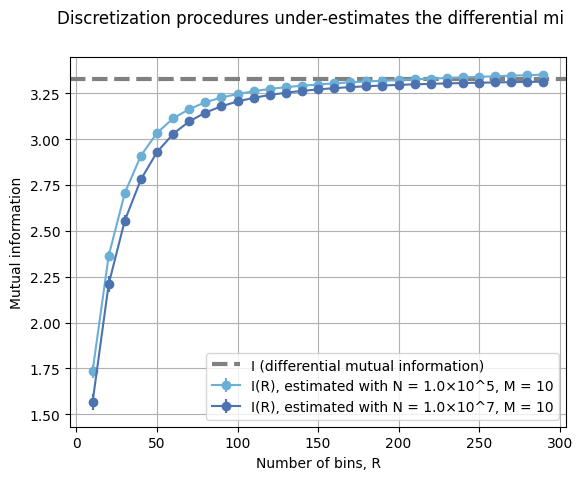

In [10]:
def sci10(x):
    s = f"{x:.1e}"
    mant, exp = s.split("e")
    return f"{mant}×10^{int(exp)}"


sigma_ = 0.1
I = nlib.mi_gaussian_analytic(sigma_**2)
M = 10

bins = np.arange(10, 300, 10)
results = np.zeros((len(bins), M))


N1 = 10**5  # number of samples
N2 = 10**7

colors = ["#6baed6", "#4c72b0"]  

fig, ax = plt.subplots()


for idx,N in enumerate([N1, N2]):
    for m in range(M):
        data = nlib.generate_data(N, sigma_)
        for i, bin in enumerate(bins):
            results[i, m] = mi_binning_2d_numba(data, bin)

    mean = np.mean(results, axis = 1)
    std = np.std(results, axis = 1)
    ax.errorbar(bins, mean, std, color =  colors[idx], marker =  "o", label = f"I(R), estimated with N = {sci10(N)}, M = {M}")



ax.axhline(I, color = "grey", linestyle = "dashed", lw = 3, label = "I (differential mutual information)")
ax.set_xlabel("Number of bins, R")
ax.set_ylabel("Mutual information")
ax.legend()

ax.grid()
plt.suptitle("Discretization procedures under-estimates the differential mi")
plt.show()

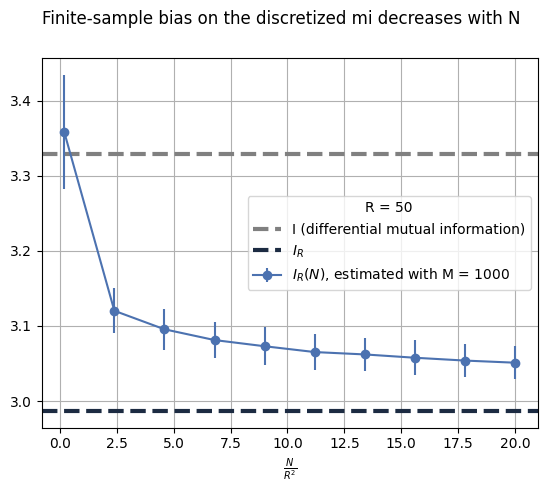

In [14]:
##
R = 50
N_large = 10**6
data = nlib.generate_data(N_large, sigma_) # very large dataset
I_R = mi_binning_2d_numba(data, R)
##


M = 1000
N_values = np.linspace(0.2* R**2, 20*R**2, 10, dtype = int)
results = np.zeros((len(N_values), M))


for i, nval in enumerate(N_values):
    for m in range(M):
        data = nlib.generate_data(nval, sigma_)
        results[i, m] = mi_binning_2d_numba(data, R)

mean = np.mean(results, axis = 1)
std = np.std(results, axis = 1)


fig, ax = plt.subplots()
ax.axhline(I, color = "grey", lw = 3, linestyle = "dashed", label = "I (differential mutual information)")
ax.axhline(I_R, color = "#1c2b42", lw = 3, linestyle = "dashed", label = r"$I_R$")
ax.errorbar(N_values/(R**2), mean, std, color = "#4c72b0", marker =  "o", label = rf"$I_R(N)$, estimated with M = {M}")


ax.set_xlabel(r"$\frac{N}{R^2}$")
ax.legend()

plt.suptitle("Finite-sample bias on the discretized mi decreases with N")
ax.legend(title = f"R = {R}")
ax.grid()
plt.show()

## Bias correction

In [15]:
@njit
def NEW_entropy_core(counts):
    total = np.sum(counts)
    if total == 0:
        return 0.0

    res = 0.0
    for i in range(len(counts)):
        c = counts[i]
        if c > 0:
            p = c / total
            res -= p * np.log2(p)
    return res

@njit
def NEW_bin_data_1d(x, n_bins, x_min, x_max):
    """
    Return bin count and number of bins with at least one count
    """
    counts = np.zeros(n_bins, dtype=np.int64)

    # degenerate case
    if x_max == x_min:
        return counts, 0

    width = (x_max - x_min) / n_bins

    for i in range(len(x)):
        idx = int((x[i] - x_min) / width)
        if idx >= n_bins:
            idx = n_bins - 1
        elif idx < 0:
            idx = 0
        counts[idx] += 1

    n_populated_bins = 0
    for i in range(n_bins):
        if counts[i] > 0:
            n_populated_bins += 1

    return counts, n_populated_bins

@njit
def NEW_entropy_absolute(X, n_bins):
    counts, n_populated_bins = NEW_bin_data_1d(X, n_bins, X.min(), X.max())
    return NEW_entropy_core(counts), n_populated_bins

@njit
def NEW_entropy_conditional(S, X, n_bins):
    """
    Returns entropy and number of bins with at least one count in the 2D grid
    """
    n_obs = len(S)

    s_min, s_max = S.min(), S.max()
    x_min, x_max = X.min(), X.max()

    s_width = (s_max - s_min) / n_bins if s_max > s_min else 1.0
    x_width = (x_max - x_min) / n_bins if x_max > x_min else 1.0

    counts_2d = np.zeros((n_bins, n_bins), dtype=np.int64)
    s_bin_totals = np.zeros(n_bins, dtype=np.int64)

    for j in range(n_obs):
        s_idx = int((S[j] - s_min) / s_width) if s_width > 0 else 0
        x_idx = int((X[j] - x_min) / x_width) if x_width > 0 else 0

        if s_idx >= n_bins:
            s_idx = n_bins - 1
        elif s_idx < 0:
            s_idx = 0

        if x_idx >= n_bins:
            x_idx = n_bins - 1
        elif x_idx < 0:
            x_idx = 0

        counts_2d[s_idx, x_idx] += 1
        s_bin_totals[s_idx] += 1

    h_cond = 0.0

    s_populated_bins = 0
    for i in range(n_bins):
        subset_size = s_bin_totals[i]
        if subset_size > 0:
            s_populated_bins += 1
            p_s = subset_size / n_obs
            h_cond += p_s * NEW_entropy_core(counts_2d[i, :])



    # count populated bins
    joint_pop_bins = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if counts_2d[i, j] > 0:
                joint_pop_bins += 1


    return h_cond, joint_pop_bins, s_populated_bins

@njit
def NEW_entropy_binning_absolute(data, bin_number):
    X = data[:, 1]
    return NEW_entropy_absolute(X, bin_number)


@njit
def NEW_entropy_binning_conditional(data, bin_number):
    S = data[:, 0]
    X = data[:, 1]
    return NEW_entropy_conditional(S, X, bin_number)
@njit
def NEW_mi_binning_2d(data, bin_number, bias_correction=False):
    Hx, x_populated_bins = NEW_entropy_binning_absolute(data, bin_number)
    Hx_given_s, joint_populated_bins, s_populated_bins = NEW_entropy_binning_conditional(data, bin_number)

    MI = Hx - Hx_given_s

    if bias_correction:
        N = data.shape[0]
        bias = (1 / (2 * N * np.log(2))) * (
            joint_populated_bins - x_populated_bins - (s_populated_bins - 1)
        )
        return MI - bias

    return MI

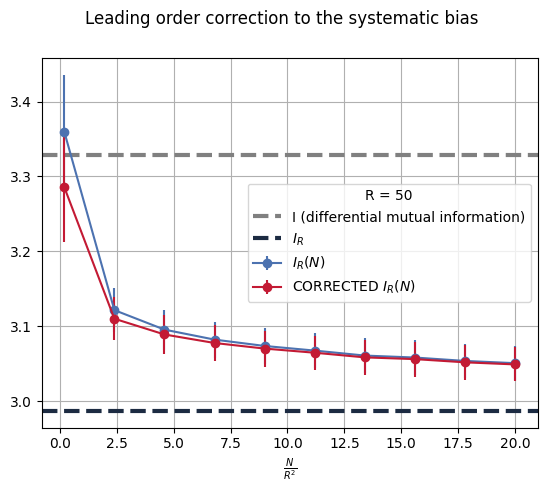

In [17]:
results = np.zeros((len(N_values), M))
corrected_results = np.zeros((len(N_values), M))

for i, nval in enumerate(N_values):
    for m in range(M):
        data = nlib.generate_data(nval, sigma_)
        results[i, m] = mi_binning_2d_numba(data, R)
        corrected_results[i, m] = NEW_mi_binning_2d(data, R, bias_correction = True)

mean = np.mean(results, axis = 1)
std = np.std(results, axis = 1)

corrected_mean = np.mean(corrected_results, axis = 1)
corrected_std = np.std(corrected_results, axis = 1)

fig, ax = plt.subplots()
ax.axhline(I, color = "grey", lw = 3, linestyle = "dashed", label = "I (differential mutual information)")
ax.axhline(I_R, color = "#1c2b42", lw = 3, linestyle = "dashed", label = r"$I_R$")

ax.errorbar(N_values/(R**2), mean, std, color = "#4c72b0", marker =  "o", label = rf"$I_R(N)$")
ax.errorbar(N_values/(R**2), corrected_mean, corrected_std, color = "#c31a34", marker =  "o", label = rf"CORRECTED $I_R(N)$")

ax.grid()
ax.set_xlabel(r"$\frac{N}{R^2}$")
ax.legend()

plt.suptitle("Leading order correction to the systematic bias")
ax.legend(title = f"R = {R}")


plt.show()

In practice, this correction is ineffective....

Only eliminates an insignificant fraction of the systematic bias. We cannot expect that including it or not would affect significatively our estimation of the *differential* mi.


Instead, the nice thing is that $I_R$ is biased downwards, while $I_R(N)$ is biased upwards (w.r.t. $I_R$). Overall we can hope that, for good choices of R, the two biases compensate and $I_R(N) \simeq I$, which is our ultimate goal.




One last thing: we have implemented a knee detection to choose the optimal bin number, but let's see instead how the simple ansaltz $R = \sqrt(N)$ would perform (with and without bias correction) in approximating $I$.

In [30]:
M = 10


N_values = np.linspace(2*10**2, 10**4, 10, dtype = int)
R_values = np.array(np.sqrt(N_values), dtype = int)


results = np.zeros((len(N_values), M))
corrected_results = np.zeros((len(N_values), M))

for i, nval in enumerate(N_values):
    R = R_values[i]
    for m in range(M):
        data = nlib.generate_data(nval, sigma_)
        results[i, m] = mi_binning_2d_numba(data, R)
        corrected_results[i, m] = NEW_mi_binning_2d(data, R, bias_correction = True)

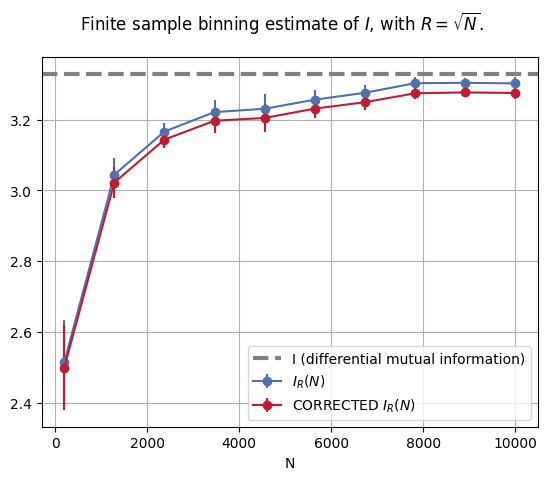

In [31]:
mean = np.mean(results, axis = 1)
std = np.std(results, axis = 1)

corrected_mean = np.mean(corrected_results, axis = 1)
corrected_std = np.std(corrected_results, axis = 1)

fig, ax = plt.subplots()
ax.axhline(I, color = "grey", lw = 3, linestyle = "dashed", label = "I (differential mutual information)")
ax.errorbar(N_values, mean, std, color = "#4c72b0", marker =  "o", label = rf"$I_R(N)$")
ax.errorbar(N_values, corrected_mean, corrected_std, color = "#c31a34", marker =  "o", label = rf"CORRECTED $I_R(N)$")

ax.grid()
ax.set_xlabel("N")
ax.legend()

plt.suptitle(r"Finite sample binning estimate of $I$, with $R=\sqrt{N}$.")
ax.legend()


plt.show()

So....

- the simple ansaltz $R=\sqrt{N}$ works pretty well for $N > \sim 5000$
- but having so much data in unlikely in real scenarios...

So... we have learned something new,


but at the end we don't change our library, and keep on estimating the optimal bin number with the knee detection.